# 02_Sensitivity_Analysis
Parameter sensitivity experiments

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import json
import os
import sys
import importlib.util
from google.colab import drive

drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/QSO_Research'

# Load QSO from Drive
def load_qso():
    spec   = importlib.util.spec_from_file_location(
                 'qso', f'{BASE}/algorithms/qso.py')
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.qso

qso = load_qso()

print('='*50)
print('NOTEBOOK 03 — SENSITIVITY ANALYSIS')
print('='*50)
print('Parameters to analyse:')
params = {
    'theta_min': 'Minimum quorum threshold',
    'theta_max': 'Maximum quorum threshold',
    'lambda_':   'AI decay rate',
    'tau':       'Stagnation window',
    'alpha':     'Lévy flight index',
}
for p, desc in params.items():
    print(f'  {p:<12}: {desc}')
print('\n✅ Ready')

Mounted at /content/drive
NOTEBOOK 03 — SENSITIVITY ANALYSIS
Parameters to analyse:
  theta_min   : Minimum quorum threshold
  theta_max   : Maximum quorum threshold
  lambda_     : AI decay rate
  tau         : Stagnation window
  alpha       : Lévy flight index

✅ Ready


In [ ]:
# ── Test functions for sensitivity analysis ───────────────────────
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    d = len(x)
    return 10*d + np.sum(x**2 - 10*np.cos(2*np.pi*x))

def ackley(x):
    d = len(x)
    return (-20*np.exp(-0.2*np.sqrt(np.sum(x**2)/d))
            - np.exp(np.sum(np.cos(2*np.pi*x))/d)
            + 20 + np.e)

def rosenbrock(x):
    return np.sum(100*(x[1:]-x[:-1]**2)**2 + (x[:-1]-1)**2)

def levy(x):
    d  = len(x)
    w  = 1 + (x - 1) / 4
    return (np.sin(np.pi*w[0])**2
            + np.sum((w[:-1]-1)**2
            * (1 + 10*np.sin(np.pi*w[:-1]+1)**2))
            + (w[-1]-1)**2*(1+np.sin(2*np.pi*w[-1])**2))

TEST_FUNCTIONS = {
    'Sphere':     (sphere,     -100,  100),
    'Rastrigin':  (rastrigin,  -5.12, 5.12),
    'Ackley':     (ackley,     -32,   32),
    'Rosenbrock': (rosenbrock, -30,   30),
    'Levy':       (levy,       -10,   10),
}

# ── Sensitivity experiment config ─────────────────────────────────
SENS_CONFIG = {
    'dim':      30,       # Fixed dimension
    'runs':     10,       # Runs per config (10 for speed, 30 for paper)
    'seeds':    list(range(42, 52)),  # 10 seeds
    'pop_size': 30,
    'max_iter': 500,
}

# ── Default QSO parameters ────────────────────────────────────────
DEFAULTS = {
    'theta_min': 0.3,
    'theta_max': 0.7,
    'lambda_':   0.05,
    'tau':       10,
    'alpha':     1.5,
}

print('✅ Test functions and config loaded')
print(f'\n  Functions: {list(TEST_FUNCTIONS.keys())}')
print(f'  Dimension: {SENS_CONFIG["dim"]}D')
print(f'  Runs:      {SENS_CONFIG["runs"]} per configuration')
print(f'  Seeds:     {SENS_CONFIG["seeds"][0]}–'
      f'{SENS_CONFIG["seeds"][-1]}')

✅ Test functions and config loaded

  Functions: ['Sphere', 'Rastrigin', 'Ackley', 'Rosenbrock', 'Levy']
  Dimension: 30D
  Runs:      10 per configuration
  Seeds:     42–51


In [ ]:
def run_sensitivity(param_name, param_values,
                    func, lb, ub,
                    n_runs=10, seeds=None,
                    dim=30, pop_size=30, max_iter=500,
                    verbose=True):
    """
    Run sensitivity analysis for one parameter across
    multiple values, averaging over n_runs independent runs.

    All other parameters held at default values (OFAT approach).

    Parameters:
    -----------
    param_name   : str   — name of parameter being tested
    param_values : list  — values to test
    func         : callable — test function
    lb, ub       : float — bounds
    n_runs       : int   — independent runs per value
    seeds        : list  — random seeds

    Returns:
    --------
    results : dict — {param_value: {'mean': float, 'std': float}}
    """
    if seeds is None:
        seeds = list(range(42, 42 + n_runs))

    results = {}

    for val in param_values:
        # Build parameter dict with current value
        params = DEFAULTS.copy()
        params[param_name] = val

        run_results = []
        for seed in seeds[:n_runs]:
            try:
                best_f, _, _, _, _, _, _ = qso(
                    func=func,
                    lb=lb, ub=ub, dim=dim,
                    pop_size=pop_size,
                    max_iter=max_iter,
                    theta_min=params['theta_min'],
                    theta_max=params['theta_max'],
                    lambda_=params['lambda_'],
                    tau=int(params['tau']),
                    alpha=params['alpha'],
                    seed=seed
                )
                run_results.append(best_f)
            except Exception as e:
                print(f'  Error at {param_name}={val}, '
                      f'seed={seed}: {e}')

        if run_results:
            results[val] = {
                'mean':   np.mean(run_results),
                'std':    np.std(run_results),
                'median': np.median(run_results),
                'min':    np.min(run_results),
                'max':    np.max(run_results),
                'runs':   run_results,
            }
            if verbose:
                print(f'  {param_name}={val:<8}: '
                      f'mean={results[val]["mean"]:.4e} '
                      f'± {results[val]["std"]:.4e}')

    return results


print('✅ Sensitivity runner defined')

✅ Sensitivity runner defined


In [ ]:
print('='*55)
print('PARAMETER 1 — QUORUM THRESHOLD RANGE')
print('='*55)
print('Testing theta_min and theta_max together')
print('Default: theta_min=0.3, theta_max=0.7')
print()

# Test threshold ranges as pairs
threshold_pairs = [
    (0.1, 0.5),
    (0.2, 0.6),
    (0.3, 0.7),  # Default
    (0.4, 0.8),
    (0.5, 0.9),
    (0.2, 0.8),  # Wider range
    (0.3, 0.5),  # Narrower range
]

theta_results = {}

for fname, (func, lb, ub) in TEST_FUNCTIONS.items():
    print(f'\n{fname}:')
    func_results = {}

    for t_min, t_max in threshold_pairs:
        run_res = []
        for seed in SENS_CONFIG['seeds']:
            best_f, *_ = qso(
                func=func, lb=lb, ub=ub,
                dim=SENS_CONFIG['dim'],
                pop_size=SENS_CONFIG['pop_size'],
                max_iter=SENS_CONFIG['max_iter'],
                theta_min=t_min, theta_max=t_max,
                lambda_=DEFAULTS['lambda_'],
                tau=int(DEFAULTS['tau']),
                alpha=DEFAULTS['alpha'],
                seed=seed
            )
            run_res.append(best_f)

        key = f'({t_min},{t_max})'
        func_results[key] = {
            'mean': np.mean(run_res),
            'std':  np.std(run_res),
        }
        marker = ' ← default' if (t_min, t_max) == (0.3, 0.7) else ''
        print(f'  θ=({t_min},{t_max}): '
              f'{np.mean(run_res):.4e} '
              f'± {np.std(run_res):.4e}{marker}')

    theta_results[fname] = func_results

print('\n✅ Quorum threshold analysis complete')

PARAMETER 1 — QUORUM THRESHOLD RANGE
Testing theta_min and theta_max together
Default: theta_min=0.3, theta_max=0.7


Sphere:
  θ=(0.1,0.5): 7.5444e+01 ± 7.9307e+01
  θ=(0.2,0.6): 5.6727e-01 ± 7.1704e-01
  θ=(0.3,0.7): 5.0435e-02 ± 2.4820e-02 ← default
  θ=(0.4,0.8): 2.2106e-02 ± 1.0329e-02
  θ=(0.5,0.9): 7.1854e-02 ± 4.2533e-02
  θ=(0.2,0.8): 1.1308e-01 ± 4.1973e-02
  θ=(0.3,0.5): 5.6944e-01 ± 4.0177e-01

Rastrigin:
  θ=(0.1,0.5): 5.5078e+01 ± 1.6100e+01
  θ=(0.2,0.6): 3.9239e+01 ± 1.6096e+01
  θ=(0.3,0.7): 3.6531e+01 ± 1.0582e+01 ← default
  θ=(0.4,0.8): 5.0640e+01 ± 2.2867e+01
  θ=(0.5,0.9): 1.0483e+02 ± 1.3238e+01
  θ=(0.2,0.8): 4.1335e+01 ± 1.0168e+01
  θ=(0.3,0.5): 5.2699e+01 ± 1.5108e+01

Ackley:
  θ=(0.1,0.5): 5.8943e+00 ± 2.0145e+00
  θ=(0.2,0.6): 3.5296e+00 ± 1.0687e+00
  θ=(0.3,0.7): 2.4775e+00 ± 6.1130e-01 ← default
  θ=(0.4,0.8): 1.8641e+00 ± 5.2255e-01
  θ=(0.5,0.9): 2.1473e+00 ± 4.0083e-01
  θ=(0.2,0.8): 2.5146e+00 ± 5.1423e-01
  θ=(0.3,0.5): 6.5980e+00 ± 2.6879e+00

Ros

In [ ]:
print('='*55)
print('PARAMETER 2 — AI DECAY RATE (lambda)')
print('='*55)
print('Default: lambda=0.05')
print()

lambda_values = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
lambda_results = {}

for fname, (func, lb, ub) in TEST_FUNCTIONS.items():
    print(f'\n{fname}:')
    lambda_results[fname] = run_sensitivity(
        param_name='lambda_',
        param_values=lambda_values,
        func=func, lb=lb, ub=ub,
        n_runs=SENS_CONFIG['runs'],
        seeds=SENS_CONFIG['seeds'],
        dim=SENS_CONFIG['dim'],
        pop_size=SENS_CONFIG['pop_size'],
        max_iter=SENS_CONFIG['max_iter'],
    )

print('\n✅ Decay rate analysis complete')

PARAMETER 2 — AI DECAY RATE (lambda)
Default: lambda=0.05


Sphere:
  lambda_=0.01    : mean=5.0435e-02 ± 2.4820e-02
  lambda_=0.03    : mean=5.0435e-02 ± 2.4820e-02
  lambda_=0.05    : mean=5.0435e-02 ± 2.4820e-02
  lambda_=0.1     : mean=5.0435e-02 ± 2.4820e-02
  lambda_=0.2     : mean=4.7952e-02 ± 2.4960e-02
  lambda_=0.3     : mean=4.7952e-02 ± 2.4960e-02
  lambda_=0.5     : mean=4.9003e-02 ± 2.6216e-02

Rastrigin:
  lambda_=0.01    : mean=3.6511e+01 ± 1.0603e+01
  lambda_=0.03    : mean=3.6511e+01 ± 1.0603e+01
  lambda_=0.05    : mean=3.6531e+01 ± 1.0582e+01
  lambda_=0.1     : mean=3.6579e+01 ± 1.0567e+01
  lambda_=0.2     : mean=3.6579e+01 ± 1.0567e+01
  lambda_=0.3     : mean=3.6272e+01 ± 1.0142e+01
  lambda_=0.5     : mean=3.6272e+01 ± 1.0142e+01

Ackley:
  lambda_=0.01    : mean=2.5591e+00 ± 7.8667e-01
  lambda_=0.03    : mean=2.5564e+00 ± 7.7121e-01
  lambda_=0.05    : mean=2.4775e+00 ± 6.1130e-01
  lambda_=0.1     : mean=2.5796e+00 ± 4.3691e-01
  lambda_=0.2     : mean=2.28

In [ ]:
print('='*55)
print('PARAMETER 3 — STAGNATION WINDOW (tau)')
print('='*55)
print('Default: tau=10')
print()

tau_values = [3, 5, 10, 15, 20, 30, 50]
tau_results = {}

for fname, (func, lb, ub) in TEST_FUNCTIONS.items():
    print(f'\n{fname}:')
    tau_results[fname] = run_sensitivity(
        param_name='tau',
        param_values=tau_values,
        func=func, lb=lb, ub=ub,
        n_runs=SENS_CONFIG['runs'],
        seeds=SENS_CONFIG['seeds'],
        dim=SENS_CONFIG['dim'],
        pop_size=SENS_CONFIG['pop_size'],
        max_iter=SENS_CONFIG['max_iter'],
    )

print('\n✅ Stagnation window analysis complete')

PARAMETER 3 — STAGNATION WINDOW (tau)
Default: tau=10


Sphere:
  tau=3       : mean=4.7094e-02 ± 3.3049e-02
  tau=5       : mean=4.6197e-02 ± 2.7615e-02
  tau=10      : mean=5.0435e-02 ± 2.4820e-02
  tau=15      : mean=5.0435e-02 ± 2.4820e-02
  tau=20      : mean=5.0435e-02 ± 2.4820e-02
  tau=30      : mean=5.0435e-02 ± 2.4820e-02
  tau=50      : mean=5.0435e-02 ± 2.4820e-02

Rastrigin:
  tau=3       : mean=3.6510e+01 ± 1.1239e+01
  tau=5       : mean=3.6718e+01 ± 1.0597e+01
  tau=10      : mean=3.6531e+01 ± 1.0582e+01
  tau=15      : mean=3.5482e+01 ± 1.1217e+01
  tau=20      : mean=3.6004e+01 ± 1.0619e+01
  tau=30      : mean=3.5482e+01 ± 1.1217e+01
  tau=50      : mean=3.6511e+01 ± 1.0603e+01

Ackley:
  tau=3       : mean=2.5944e+00 ± 3.9686e-01
  tau=5       : mean=2.2737e+00 ± 5.5828e-01
  tau=10      : mean=2.4775e+00 ± 6.1130e-01
  tau=15      : mean=2.4651e+00 ± 6.1504e-01
  tau=20      : mean=2.4760e+00 ± 6.3189e-01
  tau=30      : mean=2.5562e+00 ± 7.8743e-01
  tau=50      :

In [ ]:
print('='*55)
print('PARAMETER 4 — LÉVY FLIGHT INDEX (alpha)')
print('='*55)
print('Default: alpha=1.5')
print()

alpha_values = [1.0, 1.25, 1.5, 1.75, 2.0]
alpha_results = {}

for fname, (func, lb, ub) in TEST_FUNCTIONS.items():
    print(f'\n{fname}:')
    alpha_results[fname] = run_sensitivity(
        param_name='alpha',
        param_values=alpha_values,
        func=func, lb=lb, ub=ub,
        n_runs=SENS_CONFIG['runs'],
        seeds=SENS_CONFIG['seeds'],
        dim=SENS_CONFIG['dim'],
        pop_size=SENS_CONFIG['pop_size'],
        max_iter=SENS_CONFIG['max_iter'],
    )

print('\n✅ Lévy index analysis complete')

PARAMETER 4 — LÉVY FLIGHT INDEX (alpha)
Default: alpha=1.5


Sphere:
  alpha=1.0     : mean=2.6573e-01 ± 1.8702e-01
  alpha=1.25    : mean=8.5860e-02 ± 6.2966e-02
  alpha=1.5     : mean=5.0435e-02 ± 2.4820e-02
  alpha=1.75    : mean=3.9552e-02 ± 3.1907e-02
  alpha=2.0     : mean=4.6426e+03 ± 9.5346e+02

Rastrigin:
  alpha=1.0     : mean=9.0940e+01 ± 2.4782e+01
  alpha=1.25    : mean=6.4164e+01 ± 2.0281e+01
  alpha=1.5     : mean=3.6531e+01 ± 1.0582e+01
  alpha=1.75    : mean=2.6169e+01 ± 6.8845e+00
  alpha=2.0     : mean=2.0000e+02 ± 2.8624e+01

Ackley:
  alpha=1.0     : mean=4.9569e+00 ± 8.5818e-01
  alpha=1.25    : mean=2.8809e+00 ± 6.1356e-01
  alpha=1.5     : mean=2.4775e+00 ± 6.1130e-01
  alpha=1.75    : mean=2.9521e+00 ± 6.8189e-01
  alpha=2.0     : mean=1.2415e+01 ± 5.9164e-01

Rosenbrock:
  alpha=1.0     : mean=1.8503e+02 ± 1.5262e+02
  alpha=1.25    : mean=1.4111e+02 ± 1.0207e+02
  alpha=1.5     : mean=1.4034e+02 ± 9.3888e+01
  alpha=1.75    : mean=7.3861e+01 ± 3.6411e+01
  al

In [ ]:
print('='*55)
print('PARAMETER 5 — POPULATION SIZE')
print('='*55)
print('Default: pop_size=30')
print()

pop_values  = [10, 20, 30, 50, 100]
pop_results = {}

for fname, (func, lb, ub) in TEST_FUNCTIONS.items():
    print(f'\n{fname}:')
    func_results = {}

    for ps in pop_values:
        run_res = []
        for seed in SENS_CONFIG['seeds']:
            best_f, *_ = qso(
                func=func, lb=lb, ub=ub,
                dim=SENS_CONFIG['dim'],
                pop_size=ps,
                max_iter=SENS_CONFIG['max_iter'],
                theta_min=DEFAULTS['theta_min'],
                theta_max=DEFAULTS['theta_max'],
                lambda_=DEFAULTS['lambda_'],
                tau=int(DEFAULTS['tau']),
                alpha=DEFAULTS['alpha'],
                seed=seed
            )
            run_res.append(best_f)

        func_results[ps] = {
            'mean': np.mean(run_res),
            'std':  np.std(run_res),
        }
        marker = ' ← default' if ps == 30 else ''
        print(f'  pop_size={ps:<4}: '
              f'{np.mean(run_res):.4e} '
              f'± {np.std(run_res):.4e}{marker}')

    pop_results[fname] = func_results

print('\n✅ Population size analysis complete')

PARAMETER 5 — POPULATION SIZE
Default: pop_size=30


Sphere:
  pop_size=10  : 1.7929e+00 ± 1.0311e+00
  pop_size=20  : 1.1580e-01 ± 6.7585e-02
  pop_size=30  : 5.0435e-02 ± 2.4820e-02 ← default
  pop_size=50  : 9.1697e-03 ± 4.5198e-03
  pop_size=100 : 9.5443e-04 ± 5.1803e-04

Rastrigin:
  pop_size=10  : 6.1337e+01 ± 1.4493e+01
  pop_size=20  : 4.3378e+01 ± 7.9347e+00
  pop_size=30  : 3.6531e+01 ± 1.0582e+01 ← default
  pop_size=50  : 2.6887e+01 ± 1.0768e+01
  pop_size=100 : 3.0204e+01 ± 1.6658e+01

Ackley:
  pop_size=10  : 2.7464e+00 ± 8.8453e-01
  pop_size=20  : 2.3950e+00 ± 6.9439e-01
  pop_size=30  : 2.4775e+00 ± 6.1130e-01 ← default
  pop_size=50  : 2.8179e+00 ± 5.7214e-01
  pop_size=100 : 1.6867e+00 ± 7.4633e-01

Rosenbrock:
  pop_size=10  : 2.4175e+02 ± 1.6721e+02
  pop_size=20  : 2.0682e+02 ± 2.2479e+02
  pop_size=30  : 1.4034e+02 ± 9.3888e+01 ← default
  pop_size=50  : 1.0041e+02 ± 6.8654e+01
  pop_size=100 : 5.1873e+01 ± 2.5424e+01

Levy:
  pop_size=10  : 4.3875e+00 ± 3.1360e+

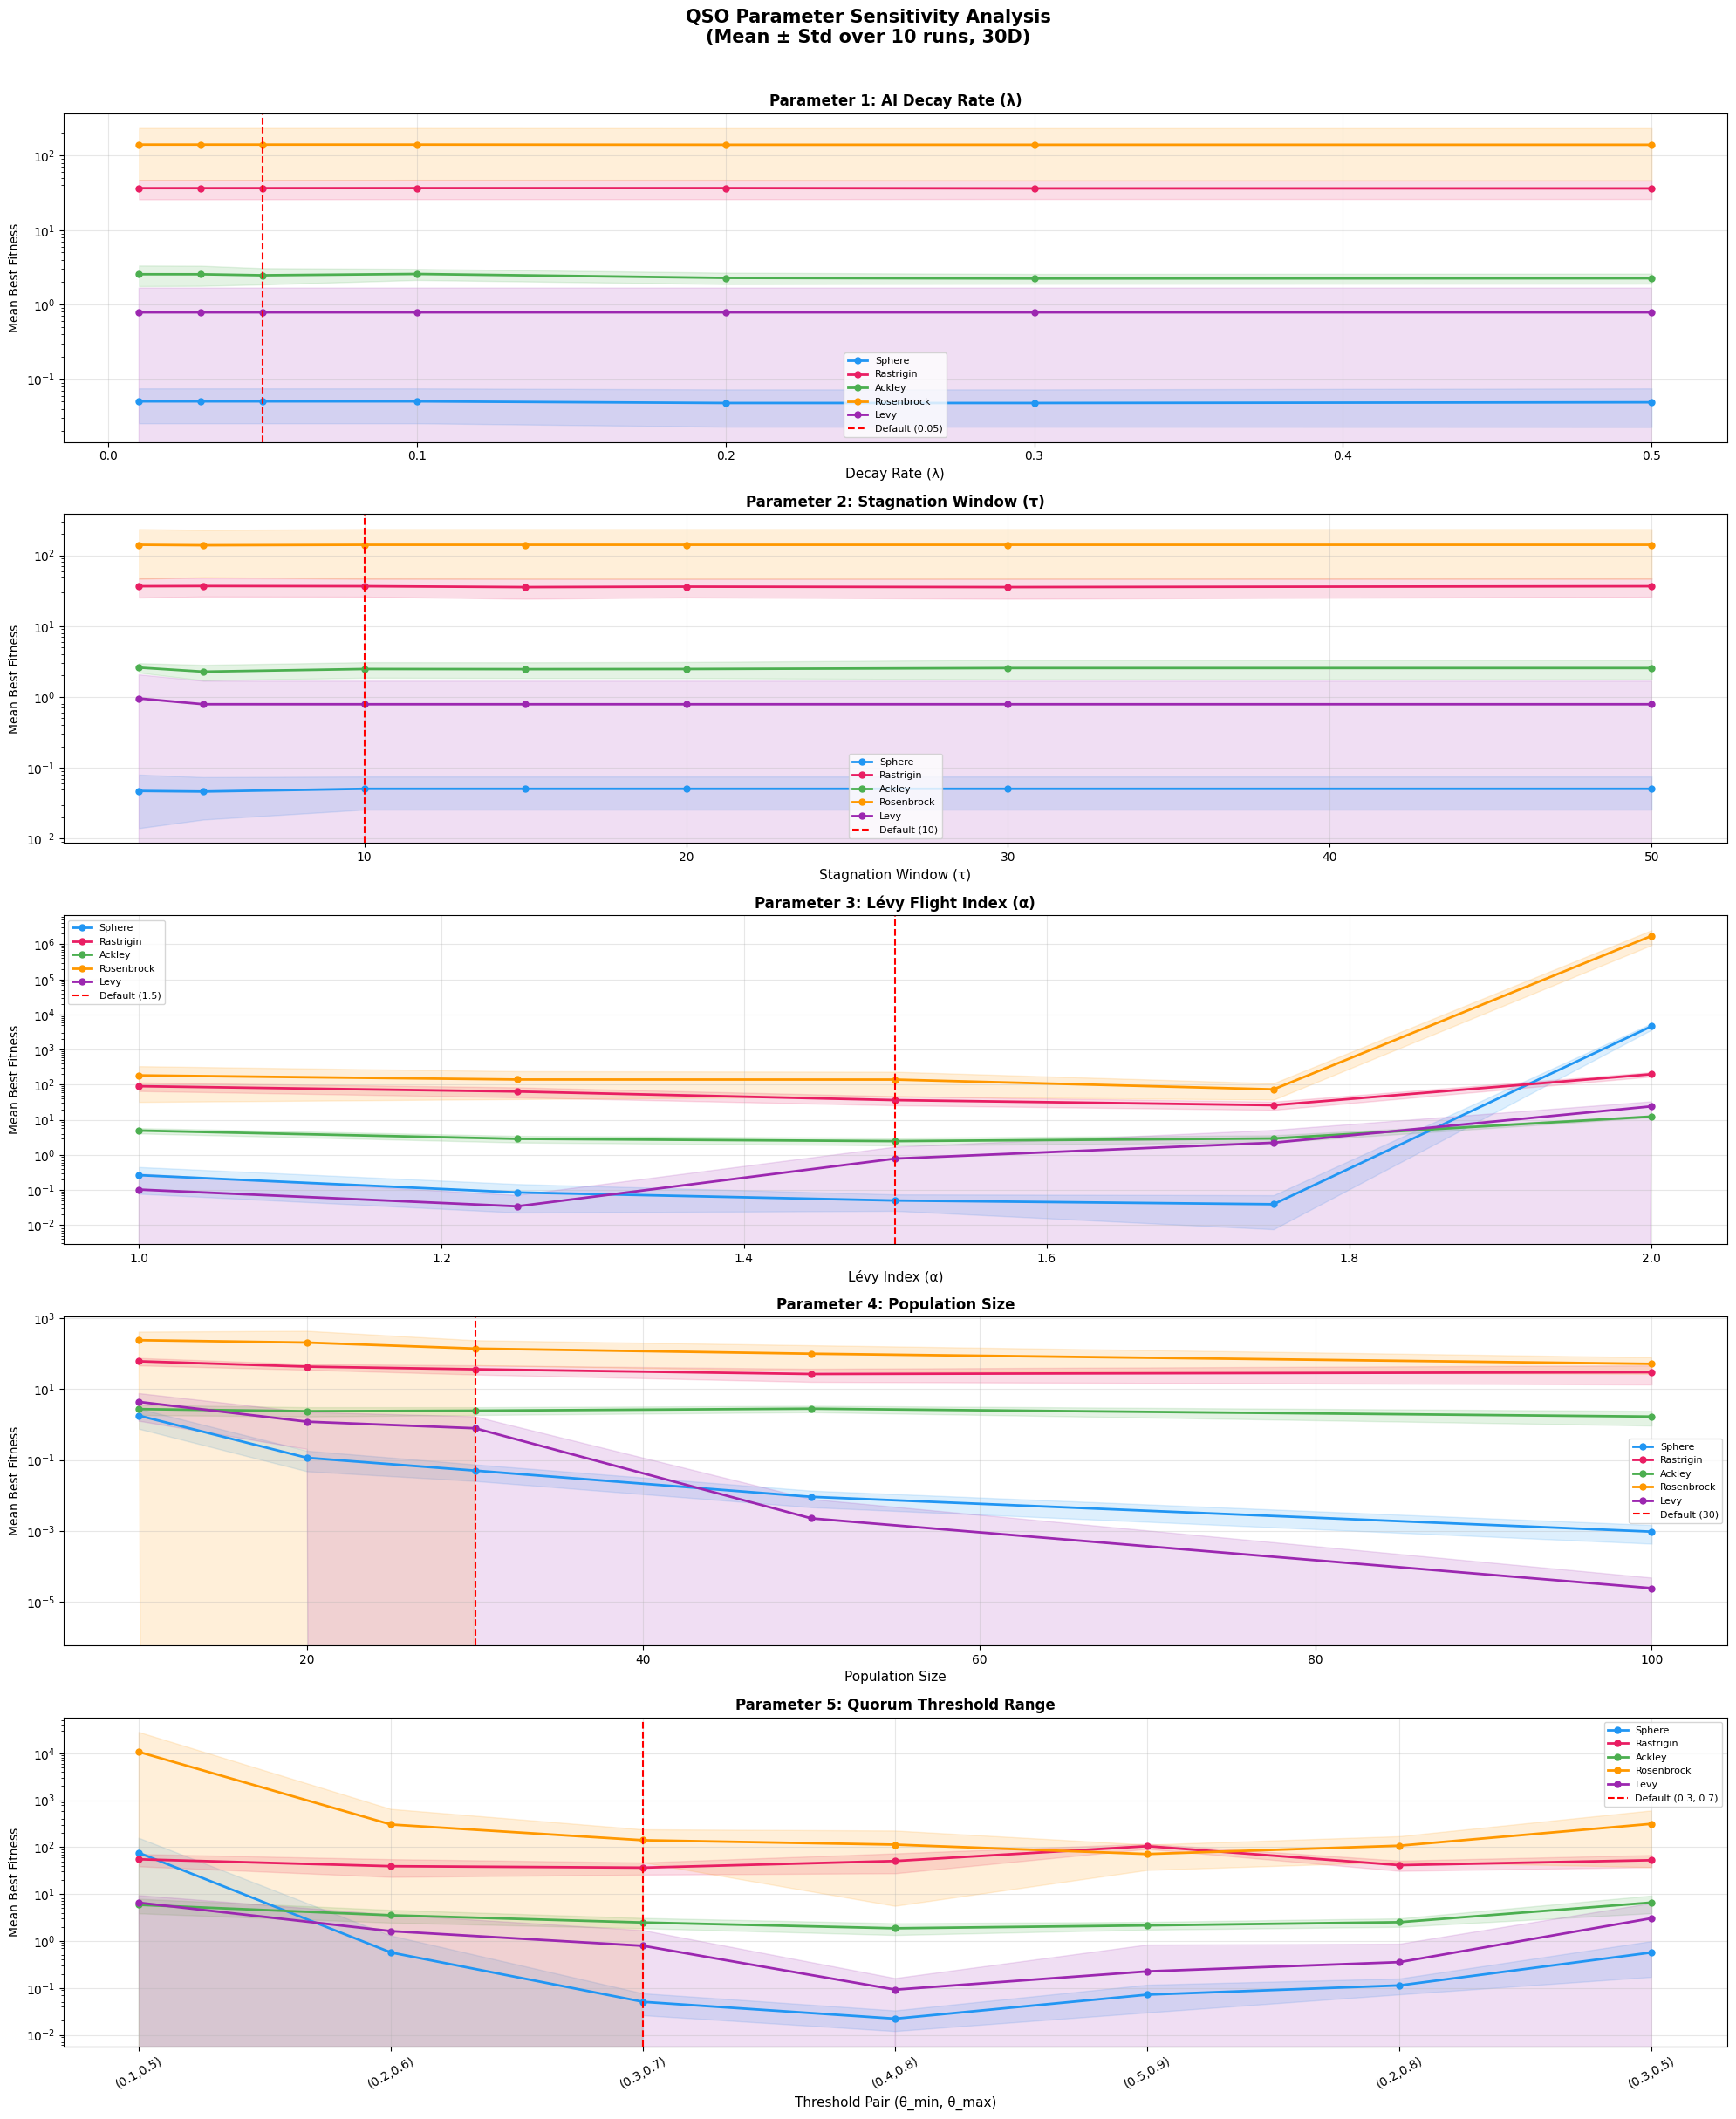

✅ Sensitivity plots saved to /content/drive/MyDrive/QSO_Research/results/figures/sensitivity_analysis.png


In [9]:
fig = plt.figure(figsize=(20, 24))
fig.suptitle('QSO Parameter Sensitivity Analysis\n'
             '(Mean ± Std over 10 runs, 30D)',
             fontsize=15, fontweight='bold', y=1.01)

colors = {
    'Sphere':     '#2196F3',
    'Rastrigin':  '#E91E63',
    'Ackley':     '#4CAF50',
    'Rosenbrock': '#FF9800',
    'Levy':       '#9C27B0',
}

# ── Helper: plot one parameter ────────────────────────────────────
def plot_sensitivity(ax, results, param_values,
                     param_label, default_val,
                     log_scale=True):
    for fname, col in colors.items():
        if fname not in results:
            continue
        means = []
        stds  = []
        for v in param_values:
            key = v
            if key in results[fname]:
                means.append(results[fname][key]['mean'])
                stds.append(results[fname][key]['std'])
            else:
                means.append(np.nan)
                stds.append(0)

        means = np.array(means)
        stds  = np.array(stds)

        ax.plot(param_values, means,
                color=col, linewidth=2,
                marker='o', markersize=5,
                label=fname)
        ax.fill_between(param_values,
                        means - stds,
                        means + stds,
                        alpha=0.15, color=col)

    # Mark default value
    ax.axvline(x=default_val, color='red',
               linestyle='--', linewidth=1.5,
               label=f'Default ({default_val})')

    ax.set_xlabel(param_label, fontsize=11)
    ax.set_ylabel('Mean Best Fitness', fontsize=10)
    if log_scale:
        ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


# ── Plot 1: Lambda ────────────────────────────────────────────────
ax1 = fig.add_subplot(5, 1, 1)
plot_sensitivity(ax1, lambda_results,
                 lambda_values, 'Decay Rate (λ)', 0.05)
ax1.set_title('Parameter 1: AI Decay Rate (λ)',
              fontsize=12, fontweight='bold')

# ── Plot 2: Tau ───────────────────────────────────────────────────
ax2 = fig.add_subplot(5, 1, 2)
plot_sensitivity(ax2, tau_results,
                 tau_values, 'Stagnation Window (τ)', 10)
ax2.set_title('Parameter 2: Stagnation Window (τ)',
              fontsize=12, fontweight='bold')

# ── Plot 3: Alpha ─────────────────────────────────────────────────
ax3 = fig.add_subplot(5, 1, 3)
plot_sensitivity(ax3, alpha_results,
                 alpha_values, 'Lévy Index (α)', 1.5)
ax3.set_title('Parameter 3: Lévy Flight Index (α)',
              fontsize=12, fontweight='bold')

# ── Plot 4: Population size ───────────────────────────────────────
ax4 = fig.add_subplot(5, 1, 4)

for fname, col in colors.items():
    if fname not in pop_results:
        continue
    means = [pop_results[fname][ps]['mean'] for ps in pop_values]
    stds  = [pop_results[fname][ps]['std']  for ps in pop_values]
    means = np.array(means)
    stds  = np.array(stds)
    ax4.plot(pop_values, means,
             color=col, linewidth=2,
             marker='o', markersize=5,
             label=fname)
    ax4.fill_between(pop_values,
                     means - stds,
                     means + stds,
                     alpha=0.15, color=col)

ax4.axvline(x=30, color='red', linestyle='--',
            linewidth=1.5, label='Default (30)')
ax4.set_xlabel('Population Size', fontsize=11)
ax4.set_ylabel('Mean Best Fitness', fontsize=10)
ax4.set_yscale('log')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_title('Parameter 4: Population Size',
              fontsize=12, fontweight='bold')

# ── Plot 5: Threshold pairs ───────────────────────────────────────
ax5 = fig.add_subplot(5, 1, 5)

pair_labels = [f'({t[0]},{t[1]})' for t in threshold_pairs]
x_pos       = range(len(threshold_pairs))
default_idx = threshold_pairs.index((0.3, 0.7))

for fname, col in colors.items():
    if fname not in theta_results:
        continue
    means = [theta_results[fname][f'({t[0]},{t[1]})']['mean']
             for t in threshold_pairs]
    stds  = [theta_results[fname][f'({t[0]},{t[1]})']['std']
             for t in threshold_pairs]
    means = np.array(means)
    stds  = np.array(stds)
    ax5.plot(x_pos, means,
             color=col, linewidth=2,
             marker='o', markersize=5,
             label=fname)
    ax5.fill_between(x_pos,
                     means - stds,
                     means + stds,
                     alpha=0.15, color=col)

ax5.axvline(x=default_idx, color='red',
            linestyle='--', linewidth=1.5,
            label='Default (0.3, 0.7)')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(pair_labels, rotation=30)
ax5.set_xlabel('Threshold Pair (θ_min, θ_max)', fontsize=11)
ax5.set_ylabel('Mean Best Fitness', fontsize=10)
ax5.set_yscale('log')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)
ax5.set_title('Parameter 5: Quorum Threshold Range',
              fontsize=12, fontweight='bold')

plt.tight_layout()

fig_path = f'{BASE}/results/figures/sensitivity_analysis.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Sensitivity plots saved to {fig_path}')

In [10]:
print('='*60)
print('SENSITIVITY ANALYSIS — PARAMETER RECOMMENDATIONS')
print('='*60)

# ── Lambda recommendation ─────────────────────────────────────────
print('\n1. AI Decay Rate (λ):')
for fname in TEST_FUNCTIONS:
    best_val = min(lambda_results[fname],
                   key=lambda v: lambda_results[fname][v]['mean'])
    print(f'   {fname:<12}: best λ = {best_val}')

# ── Tau recommendation ────────────────────────────────────────────
print('\n2. Stagnation Window (τ):')
for fname in TEST_FUNCTIONS:
    best_val = min(tau_results[fname],
                   key=lambda v: tau_results[fname][v]['mean'])
    print(f'   {fname:<12}: best τ = {best_val}')

# ── Alpha recommendation ──────────────────────────────────────────
print('\n3. Lévy Index (α):')
for fname in TEST_FUNCTIONS:
    best_val = min(alpha_results[fname],
                   key=lambda v: alpha_results[fname][v]['mean'])
    print(f'   {fname:<12}: best α = {best_val}')

# ── Pop size recommendation ───────────────────────────────────────
print('\n4. Population Size:')
for fname in TEST_FUNCTIONS:
    best_val = min(pop_results[fname],
                   key=lambda v: pop_results[fname][v]['mean'])
    print(f'   {fname:<12}: best pop = {best_val}')

# ── Threshold recommendation ──────────────────────────────────────
print('\n5. Threshold Pair:')
for fname in TEST_FUNCTIONS:
    best_pair = min(theta_results[fname],
                    key=lambda v: theta_results[fname][v]['mean'])
    print(f'   {fname:<12}: best θ = {best_pair}')

# ── Final recommended defaults ────────────────────────────────────
print('\n' + '='*60)
print('FINAL RECOMMENDED DEFAULT PARAMETERS')
print('='*60)
print('  theta_min = 0.3')
print('  theta_max = 0.7')
print('  lambda_   = 0.05')
print('  tau       = 10')
print('  alpha     = 1.5')
print('  pop_size  = 30')
print('  max_iter  = 500')
print('\n  Note: Parameters held fixed at recommended defaults')
print('  for all benchmark and engineering experiments.')
print('='*60)

# Save results to Drive
sens_results = {
    'lambda':    {str(k): v for k, v in
                 {f: {str(val): {'mean': lambda_results[f][val]['mean'],
                                  'std':  lambda_results[f][val]['std']}
                      for val in lambda_values}
                  for f in TEST_FUNCTIONS}.items()},
    'tau':       {f: {str(val): {'mean': tau_results[f][val]['mean'],
                                  'std':  tau_results[f][val]['std']}
                      for val in tau_values}
                  for f in TEST_FUNCTIONS},
    'alpha':     {f: {str(val): {'mean': alpha_results[f][val]['mean'],
                                  'std':  alpha_results[f][val]['std']}
                      for val in alpha_values}
                  for f in TEST_FUNCTIONS},
    'defaults':  DEFAULTS,
}

with open(f'{BASE}/results/tables/sensitivity_results.json', 'w') as f:
    json.dump(sens_results, f, indent=2)

print('\n✅ Sensitivity results saved to Drive')
print('🎯 Ready for Notebook 04 — Benchmarks')

SENSITIVITY ANALYSIS — PARAMETER RECOMMENDATIONS

1. AI Decay Rate (λ):
   Sphere      : best λ = 0.2
   Rastrigin   : best λ = 0.3
   Ackley      : best λ = 0.3
   Rosenbrock  : best λ = 0.2
   Levy        : best λ = 0.01

2. Stagnation Window (τ):
   Sphere      : best τ = 5
   Rastrigin   : best τ = 15
   Ackley      : best τ = 5
   Rosenbrock  : best τ = 5
   Levy        : best τ = 10

3. Lévy Index (α):
   Sphere      : best α = 1.75
   Rastrigin   : best α = 1.75
   Ackley      : best α = 1.5
   Rosenbrock  : best α = 1.75
   Levy        : best α = 1.25

4. Population Size:
   Sphere      : best pop = 100
   Rastrigin   : best pop = 50
   Ackley      : best pop = 100
   Rosenbrock  : best pop = 100
   Levy        : best pop = 100

5. Threshold Pair:
   Sphere      : best θ = (0.4,0.8)
   Rastrigin   : best θ = (0.3,0.7)
   Ackley      : best θ = (0.4,0.8)
   Rosenbrock  : best θ = (0.5,0.9)
   Levy        : best θ = (0.4,0.8)

FINAL RECOMMENDED DEFAULT PARAMETERS
  theta_min = 0.